In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             recall_score, f1_score, precision_score)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams['figure.figsize'] = (14, 5)
plt.style.use('seaborn-v0_8-whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow : {tf.__version__}")

I0000 00:00:1776075832.880384   45457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776075832.933238   45457 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776075835.936342   45457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0


In [2]:
DATA_PATH = Path("/workspaces/industrial-ai-predictive-maintenance/data/raw/SKAB/data")

dfs = []
for folder in ["valve1", "valve2", "other"]:
    for f in sorted((DATA_PATH / folder).glob("*.csv")):
        df = pd.read_csv(f, sep=";", index_col="datetime", parse_dates=True)
        df["source"] = folder
        dfs.append(df)

df_all = pd.concat(dfs, join="outer").sort_index()

sensor_cols = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
               'Pressure', 'Temperature', 'Thermocouple',
               'Voltage', 'Volume Flow RateRMS']

df_all[sensor_cols] = df_all[sensor_cols].fillna(df_all[sensor_cols].median())
df_work = df_all[sensor_cols + ['anomaly']].reset_index(drop=True)

# Split : train sur données normales uniquement
df_normal  = df_work[df_work['anomaly'] == 0][sensor_cols].reset_index(drop=True)
df_full    = df_work[sensor_cols].reset_index(drop=True)
labels     = df_work['anomaly'].astype(int).values

# Normalisation
scaler = StandardScaler()
X_train_raw = scaler.fit_transform(df_normal)
X_all_raw   = scaler.transform(df_full)

print(f"Train (normal) : {X_train_raw.shape}")
print(f"All data       : {X_all_raw.shape}")
print(f"Anomalies      : {labels.mean()*100:.1f}%")

Train (normal) : (24334, 8)
All data       : (37401, 8)
Anomalies      : 34.9%


In [3]:
# Le LSTM travaille sur des fenêtres temporelles, pas des points isolés
WINDOW = 30  # 30 secondes de contexte

def make_sequences(data, window):
    sequences = []
    for i in range(len(data) - window + 1):
        sequences.append(data[i:i+window])
    return np.array(sequences)

X_train_seq = make_sequences(X_train_raw, WINDOW)
X_all_seq   = make_sequences(X_all_raw, WINDOW)
labels_seq  = labels[WINDOW-1:]  # aligner les labels sur la fin de chaque fenêtre

print(f"X_train_seq : {X_train_seq.shape}  — (samples, timesteps, features)")
print(f"X_all_seq   : {X_all_seq.shape}")
print(f"labels_seq  : {labels_seq.shape}")
print(f"Anomalies   : {labels_seq.mean()*100:.1f}%")

X_train_seq : (24305, 30, 8)  — (samples, timesteps, features)
X_all_seq   : (37372, 30, 8)
labels_seq  : (37372,)
Anomalies   : 35.0%


In [4]:
def build_lstm_ae(timesteps, n_features, latent_dim=32):
    inputs = Input(shape=(timesteps, n_features))

    # Encoder
    x = LSTM(64, activation='tanh', return_sequences=False)(inputs)

    # Bottleneck — représentation compressée
    encoded = Dense(latent_dim, activation='relu')(x)

    # Decoder
    x = RepeatVector(timesteps)(encoded)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    decoded = TimeDistributed(Dense(n_features))(x)

    model = Model(inputs, decoded)
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_ae(
    timesteps=WINDOW,
    n_features=len(sensor_cols),
    latent_dim=32
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 8)          │           520 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,120 (180.16 KB)

 Trainable params: 46,120 (180.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


E0000 00:00:1776075928.763879   45457 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - loss: 0.4023 - val_loss: 0.2806
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.2919 - val_loss: 0.2661
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.2813 - val_loss: 0.2608
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.2748 - val_loss: 0.2529
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.2714 - val_loss: 0.2518
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.2703 - val_loss: 0.2508
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 0.2692 - val_loss: 0.2474
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 0.2669 - val_loss: 0.2456
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.2654 - val_loss: 0.2443
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 0.2641 - val_loss: 0.2424
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.2626 - val_loss: 0.2414
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.2615 

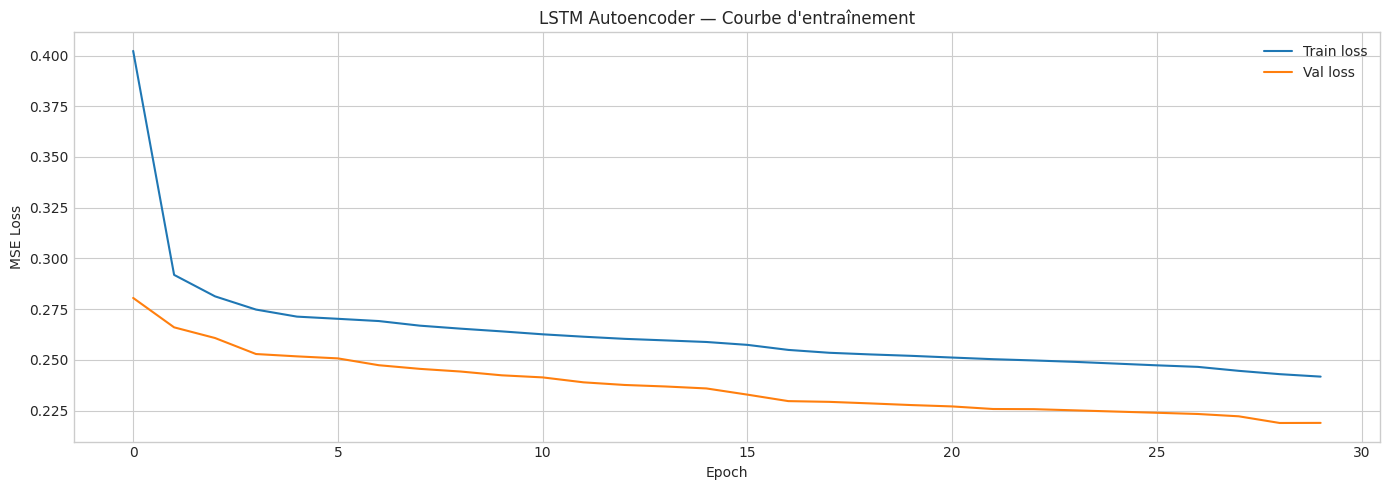

OK


In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_seq, X_train_seq,  # autoencoder : input = output
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Courbe de loss
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title("LSTM Autoencoder — Courbe d'entraînement")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/lstm_ae_training.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")

In [6]:
# Reconstruire toutes les séquences
X_pred = model.predict(X_all_seq, batch_size=256, verbose=0)

# Erreur de reconstruction par timestep — moyenne sur features
reconstruction_errors = np.mean(np.mean(np.abs(X_all_seq - X_pred), axis=2), axis=1)

print(f"Erreur moyenne — Normal   : {reconstruction_errors[labels_seq==0].mean():.4f}")
print(f"Erreur moyenne — Anomalie : {reconstruction_errors[labels_seq==1].mean():.4f}")
print(f"Ratio anomalie/normal     : {reconstruction_errors[labels_seq==1].mean() / reconstruction_errors[labels_seq==0].mean():.2f}x")

Erreur moyenne — Normal   : 0.2365
Erreur moyenne — Anomalie : 0.3683
Ratio anomalie/normal     : 1.56x


In [7]:
from sklearn.metrics import precision_recall_curve

precision_arr, recall_arr, thresholds = precision_recall_curve(labels_seq, reconstruction_errors)

f1_arr    = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-8)
best_idx  = f1_arr.argmax()
best_thr  = thresholds[best_idx]

preds_lstm = (reconstruction_errors >= best_thr).astype(int)

print(f"Seuil optimal : {best_thr:.4f}")
print(f"\n=== Résultats LSTM Autoencoder ===\n")
print(classification_report(labels_seq, preds_lstm, target_names=["Normal", "Anomalie"]))
print(f"ROC-AUC  : {roc_auc_score(labels_seq, reconstruction_errors):.4f}")
print(f"Recall   : {recall_score(labels_seq, preds_lstm):.4f}")
print(f"F1-score : {f1_score(labels_seq, preds_lstm):.4f}")

Seuil optimal : 0.1881

=== Résultats LSTM Autoencoder ===

              precision    recall  f1-score   support

      Normal       0.77      0.08      0.14     24305
    Anomalie       0.36      0.96      0.52     13067

    accuracy                           0.39     37372
   macro avg       0.56      0.52      0.33     37372
weighted avg       0.63      0.39      0.28     37372

ROC-AUC  : 0.5890
Recall   : 0.9562
F1-score : 0.5211


In [8]:
# Recharger les métriques IF pour comparaison
from sklearn.ensemble import IsolationForest

df_feat2 = df_work[sensor_cols].copy()
for col in ['Accelerometer1RMS', 'Accelerometer2RMS', 'Volume Flow RateRMS']:
    df_feat2[f'{col}_rollstd']  = df_feat2[col].rolling(30).std()
    df_feat2[f'{col}_rollmean'] = df_feat2[col].rolling(30).mean()
df_feat2['vib_flow_ratio'] = (
    (df_feat2['Accelerometer1RMS'] + df_feat2['Accelerometer2RMS']) /
    (df_feat2['Volume Flow RateRMS'] + 1e-6)
)
df_feat2 = df_feat2.dropna().reset_index(drop=True)
labels_if = df_work['anomaly'].astype(int).values[30-1:30-1+len(df_feat2)]

scaler2 = StandardScaler()
X_if = scaler2.fit_transform(df_feat2)
iso2 = IsolationForest(n_estimators=200, contamination=0.35, random_state=42, n_jobs=-1)
iso2.fit(X_if[labels_if==0])
scores_if = -iso2.score_samples(X_if)

p2, r2, t2 = precision_recall_curve(labels_if, scores_if)
f2 = 2*(p2*r2)/(p2+r2+1e-8)
preds_if2 = (scores_if >= t2[f2.argmax()]).astype(int)

# Tableau comparatif
results = pd.DataFrame({
    'Modèle'    : ['Isolation Forest', 'LSTM Autoencoder'],
    'ROC-AUC'   : [round(roc_auc_score(labels_if, scores_if), 4),
                   round(roc_auc_score(labels_seq, reconstruction_errors), 4)],
    'Recall'    : [round(recall_score(labels_if, preds_if2), 4),
                   round(recall_score(labels_seq, preds_lstm), 4)],
    'Precision' : [round(precision_score(labels_if, preds_if2), 4),
                   round(precision_score(labels_seq, preds_lstm), 4)],
    'F1'        : [round(f1_score(labels_if, preds_if2), 4),
                   round(f1_score(labels_seq, preds_lstm), 4)]
})

print("\n=== Comparaison des modèles ===\n")
print(results.to_string(index=False))


=== Comparaison des modèles ===

          Modèle  ROC-AUC  Recall  Precision     F1
Isolation Forest   0.7276  0.8656     0.4710 0.6101
LSTM Autoencoder   0.5890  0.9562     0.3582 0.5211


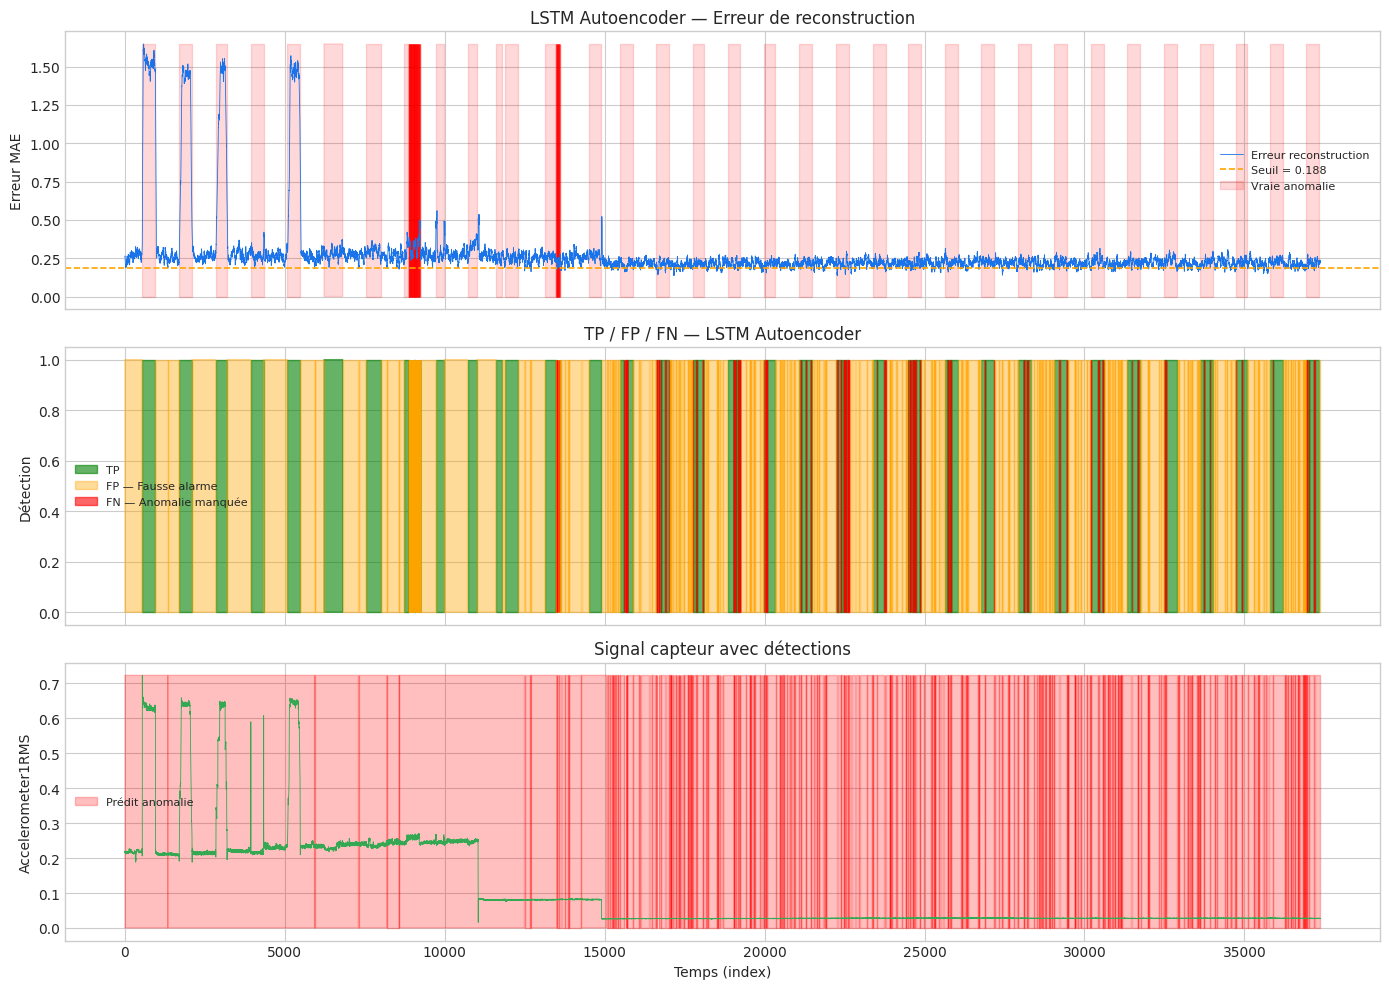

OK


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

idx = np.arange(len(labels_seq))

# Erreur de reconstruction
axes[0].plot(idx, reconstruction_errors, linewidth=0.6,
             color='#1a73e8', label='Erreur reconstruction')
axes[0].axhline(best_thr, color='orange', linestyle='--',
                linewidth=1.2, label=f'Seuil = {best_thr:.3f}')
axes[0].fill_between(idx, 0, reconstruction_errors.max(),
                     where=labels_seq==1,
                     alpha=0.15, color='red', label='Vraie anomalie')
axes[0].set_ylabel("Erreur MAE")
axes[0].legend(fontsize=8)
axes[0].set_title("LSTM Autoencoder — Erreur de reconstruction")

# TP / FP / FN
tp = (preds_lstm==1) & (labels_seq==1)
fp = (preds_lstm==1) & (labels_seq==0)
fn = (preds_lstm==0) & (labels_seq==1)

axes[1].fill_between(idx, 0, 1, where=tp, color='green',  alpha=0.6, label='TP')
axes[1].fill_between(idx, 0, 1, where=fp, color='orange', alpha=0.4, label='FP — Fausse alarme')
axes[1].fill_between(idx, 0, 1, where=fn, color='red',    alpha=0.6, label='FN — Anomalie manquée')
axes[1].set_ylabel("Détection")
axes[1].legend(fontsize=8)
axes[1].set_title("TP / FP / FN — LSTM Autoencoder")

# Accéléromètre pour contexte
axes[2].plot(idx,
             df_work['Accelerometer1RMS'].values[WINDOW-1:WINDOW-1+len(idx)],
             linewidth=0.6, color='#34a853')
axes[2].fill_between(idx, 0,
                     df_work['Accelerometer1RMS'].values[WINDOW-1:WINDOW-1+len(idx)].max(),
                     where=preds_lstm==1,
                     alpha=0.25, color='red', label='Prédit anomalie')
axes[2].set_ylabel("Accelerometer1RMS")
axes[2].set_xlabel("Temps (index)")
axes[2].legend(fontsize=8)
axes[2].set_title("Signal capteur avec détections")

plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/lstm_ae_results.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")